In [12]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

data=pd.read_csv("exoTrain.csv")

In [13]:
data.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [14]:
data.describe()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
count,5087.000000,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,...,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5.087000e+03,5087.000000,5087.000000,5087.000000,5087.000000
mean,1.007273,1.445054e+02,1.285778e+02,1.471348e+02,1.561512e+02,1.561477e+02,1.469646e+02,1.168380e+02,1.144983e+02,1.228639e+02,...,3.485578e+02,4.956476e+02,6.711211e+02,7.468790e+02,6.937372e+02,6.553031e+02,-494.784966,-544.594264,-440.239100,-300.536399
std,0.084982,2.150669e+04,2.179717e+04,2.191309e+04,2.223366e+04,2.308448e+04,2.410567e+04,2.414109e+04,2.290691e+04,2.102681e+04,...,2.864786e+04,3.551876e+04,4.349963e+04,4.981375e+04,5.087103e+04,5.339979e+04,17844.469520,17722.339334,16273.406292,14459.795577
min,1.000000,-2.278563e+05,-3.154408e+05,-2.840018e+05,-2.340069e+05,-4.231956e+05,-5.975521e+05,-6.724046e+05,-5.790136e+05,-3.973882e+05,...,-3.240480e+05,-3.045540e+05,-2.933140e+05,-2.838420e+05,-3.288214e+05,-5.028894e+05,-775322.000000,-732006.000000,-700992.000000,-643170.000000
25%,1.000000,-4.234000e+01,-3.952000e+01,-3.850500e+01,-3.505000e+01,-3.195500e+01,-3.338000e+01,-2.813000e+01,-2.784000e+01,-2.683500e+01,...,-1.760000e+01,-1.948500e+01,-1.757000e+01,-2.076000e+01,-2.226000e+01,-2.440500e+01,-26.760000,-24.065000,-21.135000,-19.820000
50%,1.000000,-7.100000e-01,-8.900000e-01,-7.400000e-01,-4.000000e-01,-6.100000e-01,-1.030000e+00,-8.700000e-01,-6.600000e-01,-5.600000e-01,...,2.600000e+00,2.680000e+00,3.050000e+00,3.590000e+00,3.230000e+00,3.500000e+00,-0.680000,0.360000,0.900000,1.430000
75%,1.000000,4.825500e+01,4.428500e+01,4.232500e+01,3.976500e+01,3.975000e+01,3.514000e+01,3.406000e+01,3.170000e+01,3.045500e+01,...,2.211000e+01,2.235000e+01,2.639500e+01,2.909000e+01,2.780000e+01,3.085500e+01,18.175000,18.770000,19.465000,20.280000
max,2.000000,1.439240e+06,1.453319e+06,1.468429e+06,1.495750e+06,1.510937e+06,1.508152e+06,1.465743e+06,1.416827e+06,1.342888e+06,...,1.779338e+06,2.379227e+06,2.992070e+06,3.434973e+06,3.481220e+06,3.616292e+06,288607.500000,215972.000000,207590.000000,211302.000000


In [15]:
check_missing=data.isnull().sum()
print(check_missing[check_missing>0])


Series([], dtype: int64)


In [16]:
scaler=StandardScaler()
X=data.drop('LABEL',axis=1)

y=data['LABEL']
y=y-1

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [17]:
from scipy.ndimage import gaussian_filter1d
import numpy as np

# 1. Apply Gaussian Smoothing to reduce deep space static/noise (sigma=3 is a great baseline)
# gaussian_filter1d takes the Pandas DataFrame and returns a smoothed numpy array
X_train_smoothed = gaussian_filter1d(X_train, sigma=3, axis=1)
X_test_smoothed = gaussian_filter1d(X_test, sigma=3, axis=1)

# 2. Calculate mean and std for each star individually (axis=1)
train_mean = X_train_smoothed.mean(axis=1).reshape(-1, 1)
train_std = X_train_smoothed.std(axis=1).reshape(-1, 1)
# Adding 1e-8 prevents division by zero in case of completely flat light curves
X_train_scaled = (X_train_smoothed - train_mean) / (train_std + 1e-8)

test_mean = X_test_smoothed.mean(axis=1).reshape(-1, 1)
test_std = X_test_smoothed.std(axis=1).reshape(-1, 1)
X_test_scaled = (X_test_smoothed - test_mean) / (test_std + 1e-8)

# 3. Reshape scaled arrays for LSTM 3D format: (samples, timesteps, features)
X_train_reshaped = np.expand_dims(X_train_scaled, axis=2)
X_test_reshaped = np.expand_dims(X_test_scaled, axis=2)


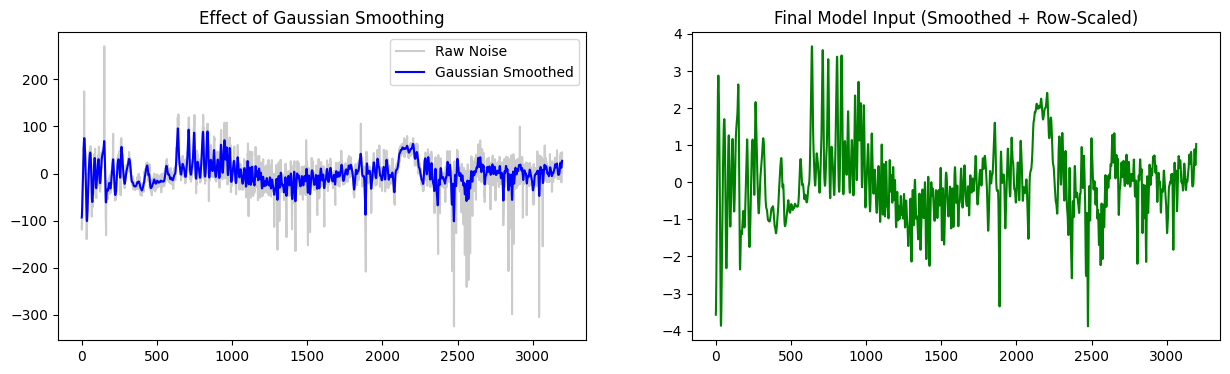

In [18]:
import matplotlib.pyplot as plt

# Find the first positive exoplanet in the shuffled training set
exoplanet_idx = np.where(y_train == 1)[0][0]

plt.figure(figsize=(15, 4))
plt.subplot(1, 2, 1)
plt.plot(X_train.iloc[exoplanet_idx].values, label="Raw Noise", alpha=0.4, color='gray')
plt.plot(X_train_smoothed[exoplanet_idx], label="Gaussian Smoothed", color='blue')
plt.title('Effect of Gaussian Smoothing')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(X_train_scaled[exoplanet_idx], color='green')
plt.title('Final Model Input (Smoothed + Row-Scaled)')
plt.show()


LABEL
0    5050
1      37
Name: count, dtype: int64


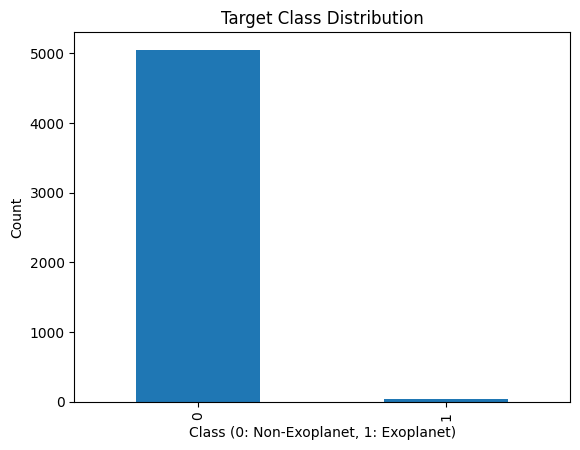

In [19]:
import matplotlib.pyplot as plt

print(y.value_counts())

y.value_counts().plot(kind="bar")
plt.title('Target Class Distribution')
plt.xlabel('Class (0: Non-Exoplanet, 1: Exoplanet)')
plt.ylabel('Count')
plt.show()


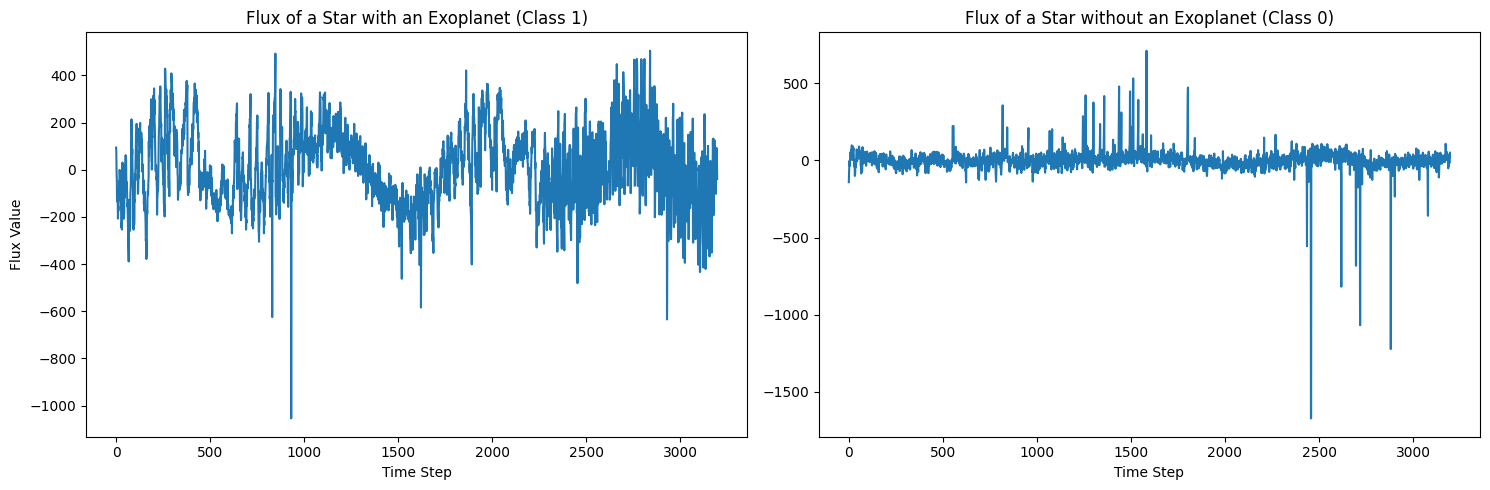

In [20]:
plt.figure(figsize=(15, 5))

# Plot one exoplanet (assuming LABEL 1 is exoplanet)
plt.subplot(1, 2, 1)
plt.plot(X[y == 1].iloc[0].values)
plt.title('Flux of a Star with an Exoplanet (Class 1)')
plt.xlabel('Time Step')
plt.ylabel('Flux Value')

# Plot one non-exoplanet
plt.subplot(1, 2, 2)
plt.plot(X[y == 0].iloc[0].values)
plt.title('Flux of a Star without an Exoplanet (Class 0)')
plt.xlabel('Time Step')

plt.tight_layout()
plt.show()


In [21]:
from tensorflow.keras.callbacks import Callback

class PrintAfterEpoch(Callback):
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        print(f"Epoch {epoch+1}: loss={logs['loss']:.4f}, accuracy={logs['accuracy']:.4f}, val_loss={logs.get('val_loss', 0):.4f}, val_accuracy={logs.get('val_accuracy', 0):.4f}")

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64,return_sequences=True,input_shape=(X_train_reshaped.shape[1],X_train_reshaped.shape[2])),
    LSTM(64,return_sequences=True,dropout=0.1),
    LSTM(32,return_sequences=True,dropout=0.2),
    LSTM(16),
    Dense(1,activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_reshaped,  # (samples, timesteps, 1)
    y_train,           # binary labels: 0 or 1
    epochs=20,         # you can start with 20
    batch_size=32,
    validation_data=(X_test_reshaped, y_test), # optional, for monitoring
    callbacks=[early_stop,PrintAfterEpoch()]
    )

history = model.fit(
    X_train_reshaped,
    y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_reshaped, y_test),
    callbacks=[early_stop]
)
loss, accuracy = model.evaluate(X_test_reshaped, y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

y_pred_prob = model.predict(X_test_reshaped)  # probabilities (0-1)
y_pred = (y_pred_prob > 0.5).astype(int)      # convert to 0 or 1


Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9431 - loss: 0.2569Epoch 1: loss=0.1202, accuracy=0.9818, val_loss=0.0435, val_accuracy=0.9931
128/128 ━━━━━━━━━━━━━━━━━━━━ 1183s 9s/step - accuracy: 0.9434 - loss: 0.2558 - val_accuracy: 0.9931 - val_loss: 0.0435
Epoch 2/20
 23/128 ━━━━━━━━━━━━━━━━━━━━ 23:10 13s/step - accuracy: 0.9940 - loss: 0.0398

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()